# **INTRODUCCIÓN A ESTADÍSTICA DESCRIPTIVA**

Práctica de análisis descriptivo utilizando medidas de tendencia central, medidas de dispersión, percentiles, correlación y visualización de datos.

## **ANÁLISIS UNIVARIABLE**

El **análisis univariable** es el análisis que se realiza a **una sola variable** a la vez. Su propósito principal es **describir la distribución, frecuencia y tendencia** de esa única característica, sin considerar relaciones de causa o efecto.

***NOTA:*** *Se hará el uso de las bibliotecas de **Pandas** y **Seaborn** para usar datasets precargados sin entrar a tanto detalle a las librerías mismas. Para ello, se explicará mas a detalle en el siguiente módulo.*

In [ ]:
#Importar librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Importar dataset
df_tips = sns.load_dataset('tips')
df_tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [ ]:
# Mostrar propiedades de la tabla
df_tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [ ]:
# Mostrar resumen estadístico
df_tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [ ]:
# Realizar una proporción de probabilidad

media = round(df_tips.describe()["total_bill"]['mean'], 3)
std= round(df_tips.describe()['total_bill']['std'], 3)
prop_prob = round((std/media)*100, 1)

print(f'Los datos se separan de la medía a un {prop_prob}%')

Los datos se separan de la medía a un 45.0%


#### **MEDIDAS DE TENDENCIA CENTRAL**

Las **medidas de tendencia central** (MTC) son métricas estadísticas que nos permiten **resumir un conjunto de datos en un solo valor**. Estas métricas nos indican cuál es el **valor que se encuentra en el centro** de un conjunto de datos.

Las medidas de tendencia central son:

*   **Media:** Es el valor promedio de un conjunto de datos y es muy sensible a los sesgos.

*   **Mediana:** Es el valor que se encuentra en el centro de un conjunto de datos ordenados y es menos sensible a los sesgos.

*   **Moda:** Es el valor que aparece con más frecuencia en un conjunto de datos.

In [ ]:
# Definir variables

media = round(df_tips['total_bill'].mean(), 2)
mediana = round(df_tips['total_bill'].median(), 2)
moda = round(df_tips['total_bill'].mode().iloc[0], 2)

print(f'Las MTC son: Media {media}, Mediana {mediana} y Moda {moda}')

Las MTC son: Media 19.79, Mediana 17.8 y Moda 13.42


In [ ]:
# Definir listas

mtc_datos = [moda, mediana, media]
mtc_nombres = ['Moda', 'Mediana', 'Media']
mtc_colores = ['green', 'red', 'blue']

mtc_configuraciones = zip(mtc_datos, mtc_nombres, mtc_colores)

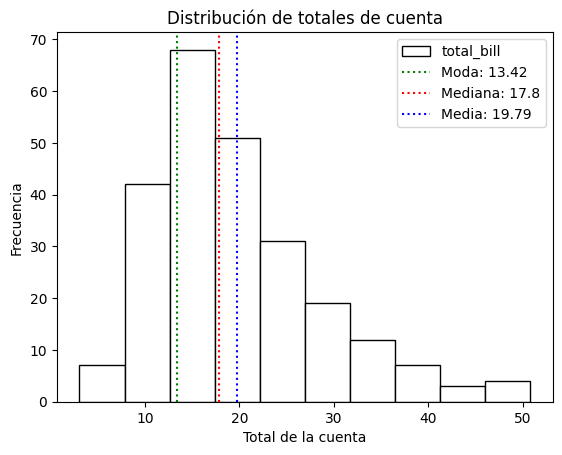

In [ ]:
# Visualizar métricas de tendencia central

df_tips['total_bill'].plot(kind = 'hist', edgecolor = 'black', color = 'white')
plt.title('Distribución de totales de cuenta')
plt.xlabel('Total de la cuenta')
plt.ylabel('Frecuencia')

for dato, nombre, color in mtc_configuraciones:
  plt.axvline(x = dato, c = color, linestyle = ':', label = f'{nombre}: {dato}')

plt.legend()
plt.show()

### **MEDIDAS DE DISPERSIÓN**

Las **medidas de dispersión** indican qué tan **extendidos o separados se encuentran los datos de una distribución** respecto a un valor central. Son fundamentales para determinar la **variabilidad y la confiabilidad** de un conjunto de datos.

Las métricas de disperción mas utilizadas son:

*   **Desviación estandar:** Es la media de las desviaciones de los datos, a mayor desviación los datos estarán más dispersos.

*   **Cuartíl:** Son los valores estadísticos que dividen una distribución en 4 partes iguales formando un **rango intercuartílico**.

#### **DESVIACIÓN ESTANDAR**

La **desviación estándar** es una medida de la dispersión de un conjunto de datos numéricos. Se calcula como la media de las desviaciones de los datos con respecto a la media.

Se interpreta como **la distancia promedio entre los datos y la media.** Una **desviación estándar baja** indica que los datos están agrupados cerca de la media, mientras que una **desviación estándar alta** indica que los datos están más dispersos.

In [ ]:
# Definir variables

x = range(len(df_tips['total_bill']))
y = df_tips['total_bill']
std = np.std(df_tips['total_bill'])

In [ ]:
# Definir listas
std_datos = [media, media + std, media - std]
std_nombres = ['media', 'desviación estándar', None]
std_colores = ['red', 'blue', 'blue']

std_configuraciones = zip(std_datos, std_nombres, std_colores)

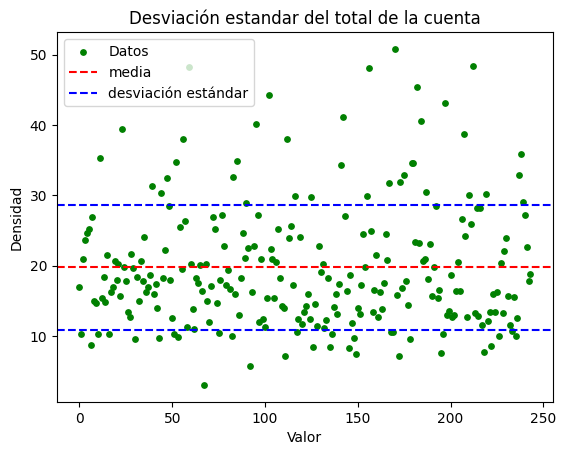

In [ ]:
# Visualizar dipersión de los datos
plt.scatter(x, y, label = 'Datos', s = 15, color = 'green')
plt.title('Desviación estandar del total de la cuenta')
plt.xlabel('Valor')
plt.ylabel('Densidad')

for dato, nombre, color in std_configuraciones:
    plt.axhline(y = dato, c = color, linestyle = '--', label = nombre)

plt.legend()
plt.show()

#### **PERCENTILES**

Los **percentiles** son valores estadísticos que dividen una distribución de datos en **100 partes iguales** (por el cual puede ser asociado como porcentaje). Se utilizan comúnmente en estadísticas y análisis de datos para entender la posición de un valor específico en relación con otros valores en un conjunto de datos.

Los percentiles pueden ser trabajados por **cuartiles**, el cual es dividir en **4 partes iguales** la misma distribución, siendo cada parte una agrupación del 25% de elementos de la distribución. Su gráfico mas representativo es el **gráfico de caja** y forma un **rango intercuartílico** (IQR) cuando se realiza la diferencia entre el primer y tercer cuartil.

In [ ]:
# Definir variables
percentil = np.percentile(df_tips['total_bill'], [25, 50, 75])

q_1 = round(percentil[0], 2)
q_3 = round(percentil[2], 2)
iqr = q_3 - q_1

np.float64(13.35)

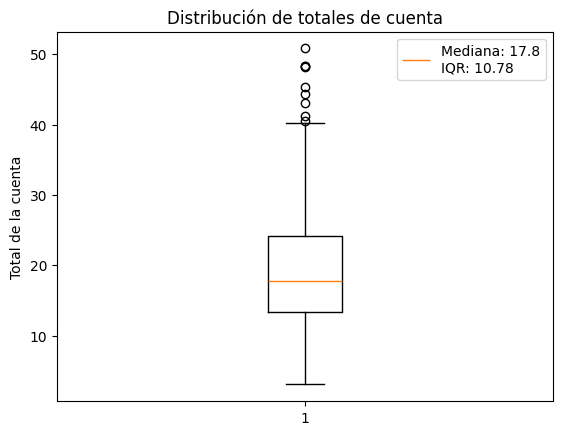

In [ ]:
# Visualizar percentiles
plt.boxplot(df_tips['total_bill'], label = f'Mediana: {mediana}\nIQR: {iqr}')
plt.title('Distribución de totales de cuenta')
plt.ylabel('Total de la cuenta')
plt.legend()
plt.show()

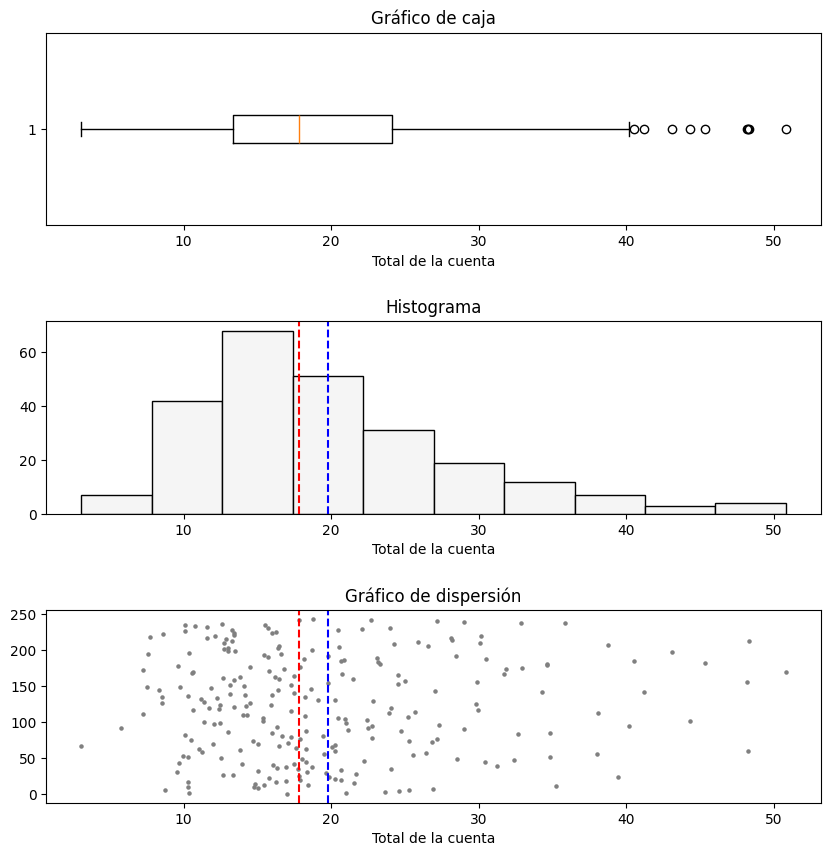

In [ ]:
# Asociar gráficos
fig, ax = plt.subplots(3, figsize = (10, 10))

fig.subplots_adjust(hspace=0.5)

ax[0].boxplot(df_tips['total_bill'], vert = False)
ax[0].set_title('Gráfico de caja')
ax[0].set_xlabel('Total de la cuenta')

ax[1].hist(df_tips['total_bill'], edgecolor = 'black', color = 'whitesmoke')
ax[1].axvline(x = mediana, linestyle = '--', color = 'red')
ax[1].axvline(x = media, linestyle = '--', color = 'blue')
ax[1].set_title('Histograma')
ax[1].set_xlabel('Total de la cuenta')

ax[2].scatter(y, x, s = 5, color = 'gray')
ax[2].axvline(x = mediana, linestyle = '--', color = 'red')
ax[2].axvline(x = media, linestyle = '--', color = 'blue')
ax[2].set_title('Gráfico de dispersión')
ax[2].set_xlabel('Total de la cuenta')

plt.show()

## **ANÁLISIS BIVARIABLE**

El **análisis bivariable** consiste en el estudio de la **relación entre dos variables** simultáneamente. Se utiliza para **determinar si existe una asociación, correlación o dependencia** entre ellas.

### **CORRELACIÓN**

La **correlación** es una medida estadística que **cuantifica la fuerza y la dirección de la relación** o asociación **entre dos o más variables**, describiendo de esa manera cómo el **cambio en una variable se asocia con el cambio en otra**.

**La correlación no implica causalidad**. Que dos variables cambien juntas **no significa necesariamente que una sea la causa de la otra**; ambos cambios podrían deberse a un tercer factor desconocido.

#### **MULTIVARIABLE**

Analiza la **interacción y los patrones entre tres o más variables** simultáneamente. Busca entender cómo múltiples factores influyen en un resultado o se agrupan entre sí.

Las **matrices de correlación** muestran los **coeficientes de correlación bivariados** para todos los pares posibles en un conjunto de datos grande.

In [ ]:
# Definir variables

columnas = ['total_bill', 'tip', 'size']
corr = df_tips[columnas].corr()
long_col = len(columnas)

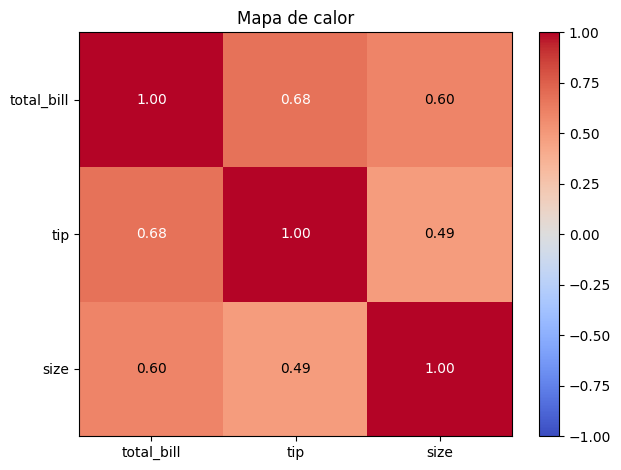

In [ ]:
# Visualizar mapa de calor
corr_inv = corr.iloc[::-1]
heatmap = plt.pcolor(corr_inv, cmap = 'coolwarm', vmin = -1, vmax = 1)

plt.title('Mapa de calor')
plt.xticks(np.arange(0.5, long_col, 1), columnas)
plt.yticks(np.arange(0.5, long_col, 1), columnas[::-1])

for i in range(len(columnas)):
    for j in range(len(columnas)):
        val = round(corr_inv.iloc[i, j], 2)
        plt.text(j + 0.5, i + 0.5, f"{val:.2f}",
                 ha = 'center', va = 'center',
                 color = 'white' if abs(val) > 0.6 else 'black')

plt.colorbar(heatmap)
plt.tight_layout()
plt.show()

#### **BIVARIABLE**

Examina la **relación entre dos variables aleatorias**. Su objetivo es determinar si existe una **asociación, dirección (positiva o negativa) y fuerza**. Algunas herramientas comunes son:

*   **Coeficiente de Pearson:** Mide la fuerza de una relación lineal entre variables cuantitativas.

*   **Diagramas de dispersión:** Gráficos de "nube de puntos" que permiten visualizar la tendencia entre las dos variables.

In [ ]:
# Definir variables
corr_cuenta_propina = round(df_tips['total_bill'].corr(df_tips['tip']), 2)
corr_mesa_cuenta = round(df_tips['size'].corr(df_tips['total_bill']), 2)
corr_mesa_propina = round(df_tips['size'].corr(df_tips['tip']), 2)

np.float64(0.68)

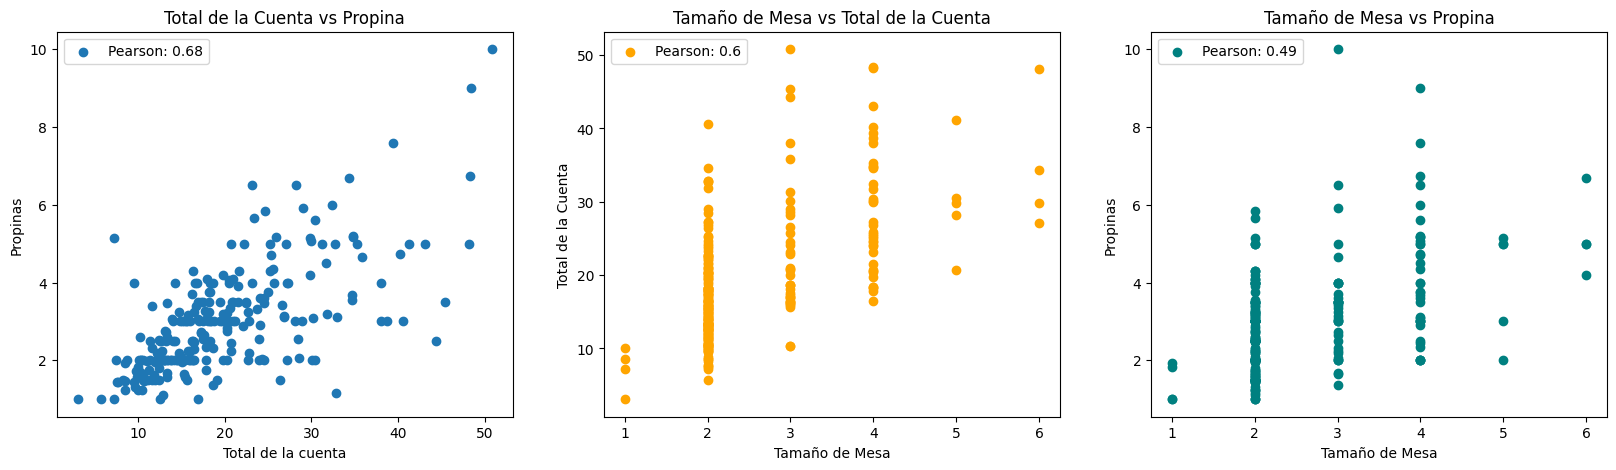

In [ ]:
# Visualizar correlaciones

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

ax[0].scatter(data = df_tips, x = 'total_bill', y = 'tip', label = f'Pearson: {corr_cuenta_propina}')
ax[0].set_title('Total de la Cuenta vs Propina')
ax[0].set_xlabel('Total de la cuenta')
ax[0].set_ylabel('Propinas')
ax[0].legend()

ax[1].scatter(data = df_tips, x = 'size', y = 'total_bill', color = 'Orange', label = f'Pearson: {corr_mesa_cuenta}')
ax[1].set_title('Tamaño de Mesa vs Total de la Cuenta')
ax[1].set_xlabel('Tamaño de Mesa')
ax[1].set_ylabel('Total de la Cuenta')
ax[1].legend(loc = 'upper left')

ax[2].scatter(data = df_tips, x = 'size', y = 'tip', color = 'teal', label = f'Pearson: {corr_mesa_propina}')
ax[2].set_title('Tamaño de Mesa vs Propina')
ax[2].set_xlabel('Tamaño de Mesa')
ax[2].set_ylabel('Propinas')
ax[2].legend(loc = 'upper left')

plt.show()

## **CHALLENGE: ANÁLISIS DESCRIPTIVO DE DATOS**

Una vez visto el ***Hands - On: Introducción a la estadística descriptiva***, se presentan las siguientes actividades para que el alumnado pueda repasar y reforzar lo aprendido dentro de la clase.

Dentro de la siguiente dinámica, **se realizará un análisis de estadística descriptiva** haciendo uso de **operaciones vectorizadas y visualización de datos** a través del **dataset taxis** proveniente de la librería de ***Seaborn***.

Donde los análisis a realizar son:

*   **Análisis univariable**
*   **Análisis bivariable**

**IMPORTANTE:** Para su revisión, **es indispensable que los apartados anteriores se encuentren llenados con el código visto durante la sesión.**

### **INSTRUCCIONES:**

**1. Importa las librerías:** Carga las bibliotecas de Numpy, Pandas, Seaborn y Matplotlib.pyplot.










In [ ]:
# Importar librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**2. Importa el dataset de taxis:** Crea una variable denominada df_taxis donde se importe el dataset taxis.

In [ ]:
# Import dataset
df_taxis = sns.load_dataset('taxis')
df_taxis

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


**3. Muestra los datos generales del dataset:**

   * Muestra las propiedades del dataset.
   * Muestra el resumen estadístico del dataset.

In [ ]:
# Mostrar propiedades de la tabla
df_taxis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [ ]:
# Mostrar resumen estadístico
df_taxis.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


**4. Realiza un análisis de univariable:**

   * Cálcula las medidas de tendencia central de la columna total.
   * Cálcula las medidas de dispersión de la columna total.
   * Visualiza los gráficos de las medidas obtenidas en un subplot de 3 columnas.

In [ ]:
# Definir medidas de tendencia central

total = df_taxis["total"].dropna()

media = np.mean(total)
mediana = np.median(total)
moda = total.mode()[0]

print("=== Medidas de tendencia central ===")
print()
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Moda: {moda:.2f}")


=== Medidas de tendencia central ===

Media: 18.52
Mediana: 14.16
Moda: 9.30


In [ ]:
# Definir medidas de dispersión
desv_std = np.std(total)
percentiles = np.percentile(total, [25, 50, 75])

print("=== Medidas de dispersión ===")
print()
print(f"Desviación estándar: {desv_std:.2f}")
print(f"Cuartil Q1: {percentiles[0]:.2f}")
print(f"Cuartil Q2: {percentiles[1]:.2f}")
print(f"Cuartil Q3: {percentiles[2]:.2f}")

=== Medidas de dispersión ===

Desviación estándar: 13.81
Cuartil Q1: 10.80
Cuartil Q2: 14.16
Cuartil Q3: 20.30


In [ ]:
# Definir variables
iqr = percentiles[2] - percentiles[0]
print(iqr)

x = range(len(total))
y = total

9.5


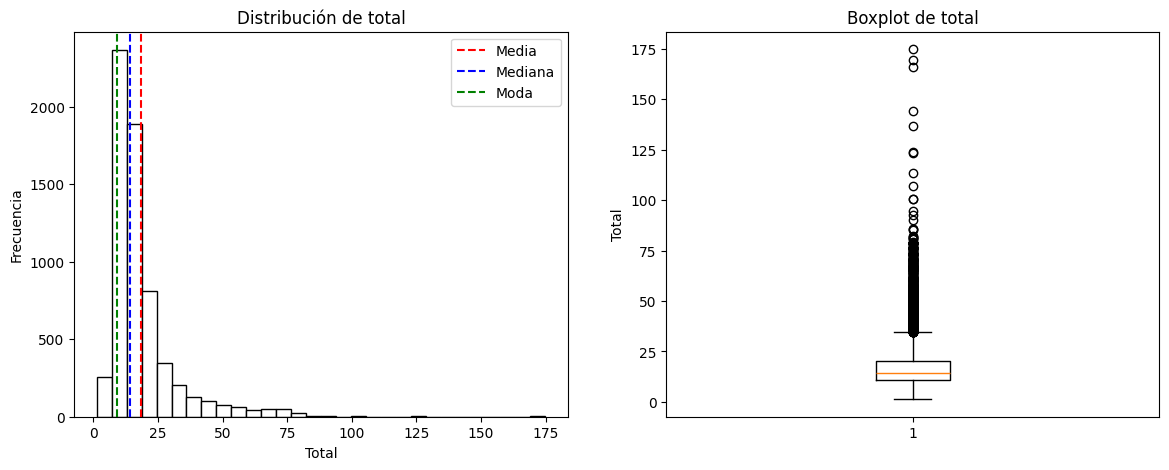

In [ ]:
# Visualizar medidas descriptivas
fig, ax = plt.subplots(1,2,figsize=(14,5))

ax[0].hist(total, bins=30, edgecolor='black', color= "white")
ax[0].axvline(media, color='red', linestyle='--', label='Media')
ax[0].axvline(mediana, color='blue', linestyle='--', label='Mediana')
ax[0].axvline(moda, color='green', linestyle='--', label='Moda')
ax[0].set_title("Distribución de total")
ax[0].set_xlabel("Total")
ax[0].set_ylabel("Frecuencia")
ax[0].legend()

ax[1].boxplot(total)
ax[1].set_title("Boxplot de total")
ax[1].set_ylabel("Total")
plt.show()

**5. Realiza un análisis de multivariable:** Visualiza en un mapa de calor los coeficientes de correlación para todos los pares posibles de las columnas numéricas del dataset.

In [ ]:
# Definir variables

df_num = df_taxis.select_dtypes(include=np.number)

corr = df_num.corr()

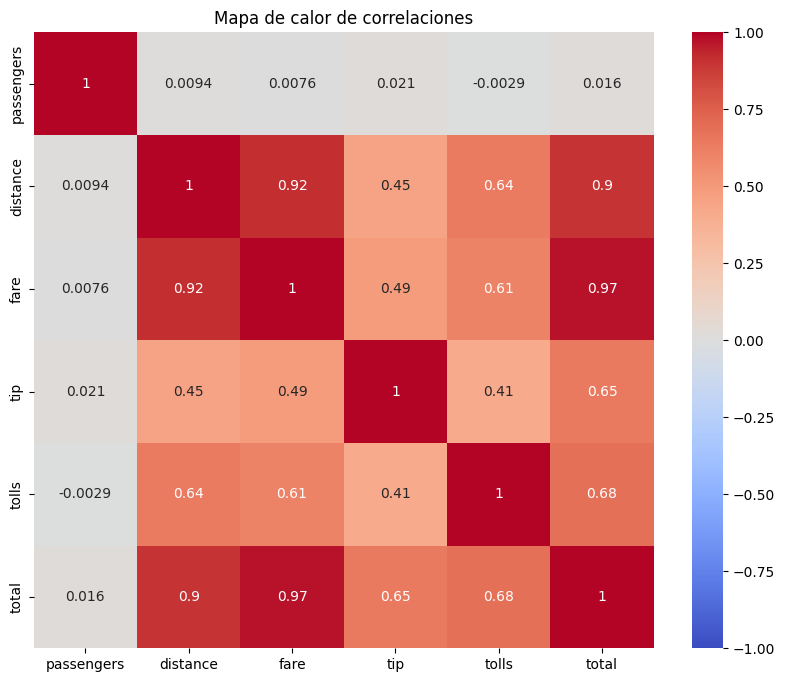

In [ ]:
# Visualizar mapa de calor
plt.figure(figsize=(10,8))

sns.heatmap(corr,annot=True,cmap='coolwarm',vmin=-1,vmax=1)

plt.title("Mapa de calor de correlaciones")
plt.show()

 **6. Realiza un análisis de bivariable:**

   * Cálcula los coeficientes de correlación de pearson de las 3 correlaciones mas fuertes obtenidas en el gráfico de calor.
   * Visualiza los gráficos de las correlaciones obtenidas en un subplot de 3 columnas.

In [ ]:
# Definir variables

corr_abs = corr.abs()

np.fill_diagonal(corr_abs.values, 0)

corr_pairs = corr_abs.unstack()

corr_pairs = corr_pairs.sort_values(ascending=False)

corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0)<corr_pairs.index.get_level_values(1)]

top3 = corr_pairs.head(3)

print(top3)

fare      total    0.974358
distance  fare     0.920108
          total    0.904676
dtype: float64


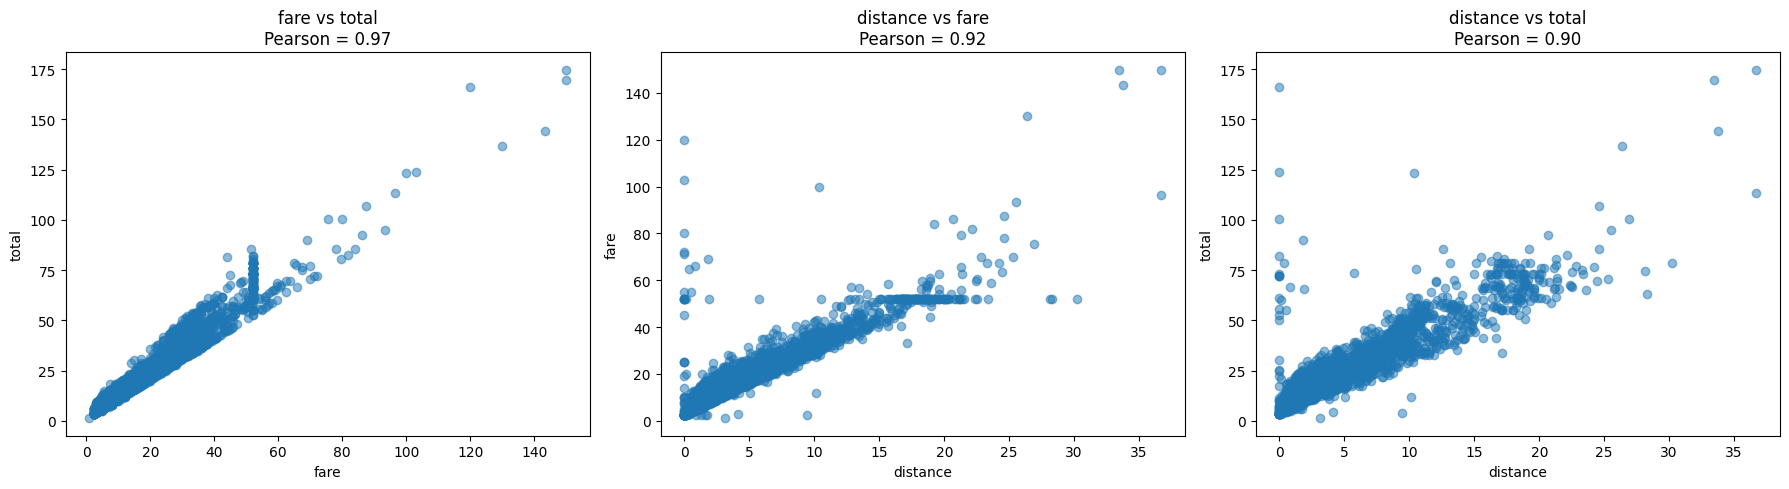

In [ ]:
# Visualizar correlaciones
fig, ax = plt.subplots(1, 3, figsize=(18,5))

for i, ((var1, var2), corr_val) in enumerate(top3.items()):

    ax[i].scatter(df_num[var1],df_num[var2], alpha=0.5)

    ax[i].set_title(
        f"{var1} vs {var2}\nPearson = {corr.loc[var1, var2]:.2f}"
    )

    ax[i].set_xlabel(var1)
    ax[i].set_ylabel(var2)

plt.tight_layout()
plt.show()